# Assignment 5 - Matilde: One ML Signal, Two Portfolio Implementations

This notebook studies an out-of-sample machine-learning stock-ranking signal for Swiss equities. The same score panel is used in two different portfolio implementations:

- a long-short top-minus-bottom strategy;
- a constrained Black-Litterman long-only strategy.

The purpose is to separate signal quality from portfolio construction. The ML model measures stock attractiveness. The implementation layer decides how that score becomes tradable weights after liquidity filters, constraints, turnover, and transaction costs.


## Research Design

The pipeline is:

```text
data
-> features
-> expanding-window ML signal
-> save/load score panel
-> long-short implementation
-> Black-Litterman implementation
-> cost-adjusted performance comparison
```

Both implementations use the same `ml_signal`. This makes the comparison clean: differences in performance come from the portfolio construction method, not from a different signal.


## Imports and Paths

We import the standard scientific stack, the local backtesting infrastructure, the portfolio construction classes, and the ML models.


In [1]:
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    import xgboost as xgb
except ImportError:
    xgb = None

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.options.display.float_format = "{:,.4f}".format


In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    """Return the repository root containing the course `src` and `data` folders."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the qpmwp-course root containing src/ and data/.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

for path in (PROJECT_ROOT, SRC_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:  {DATA_DIR}")
print(f"Results:      {RESULTS_DIR}")


Project root: C:\Users\axeli\Desktop\Coding\GitHub\University\QPM\qpmwp-course
Data folder:  C:\Users\axeli\Desktop\Coding\GitHub\University\QPM\qpmwp-course\data
Results:      C:\Users\axeli\Desktop\Coding\GitHub\University\QPM\qpmwp-course\results


In [3]:
from helper_functions import align_market_data_with_jkp_data, load_data_spi
from estimation.covariance import Covariance
from optimization.optimization import BlackLitterman, PercentilePortfolio
from backtesting.backtest import Backtest
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest_item_builder.bib_classes import (
    OptimizationItemBuilder,
    SelectionItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_box_constraints,
    bibfn_budget_constraint,
    bibfn_size_dependent_upper_bounds,
    bibfn_turnover_constraint,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_cap_weights,
    bibfn_return_series,
    bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_jkp_data_scores,
    bibfn_selection_min_volume,
)


## Configuration

The configuration keeps the signal, backtest, implementation, and cost assumptions in one place.


In [4]:
@dataclass(frozen=True)
class StrategyConfig:
    # Data and cached research outputs.
    data_dir: Path = DATA_DIR
    results_dir: Path = RESULTS_DIR
    signal_path: Path = RESULTS_DIR / "matilde_ml_signal.parquet"
    use_cached_signal: bool = True

    # Sample and rebalance schedule.
    start_date: str = "2003-01-31"
    end_date: Optional[str] = "2022-12-31"
    rebalance_months: int = 3
    lookback_days: int = 365 * 3

    # Learning target and minimum training history.
    forward_return_months: int = 3
    min_train_dates: int = 24

    # Long-short implementation.
    leg_fraction: float = 0.10
    long_weight: float = 0.5
    short_weight: float = -0.5

    # Tradability filters.
    min_volume: float = 500_000
    volume_window_days: int = 365
    max_zero_volume_gap_days: int = 10

    # Assignment cost assumptions.
    fixed_costs_annual: float = 0.01
    transaction_costs_per_rebalancing: float = 0.002

    # Black-Litterman constraints.
    stock_upper_bound: float = 0.10
    turnover_limit: float = 0.15
    tau_psi: Optional[float] = 0.02
    tau_omega: Optional[float] = 0.05
    view_gen_algo: str = "quintile_sort"
    solver_name: str = "cvxopt"

    # Signals used by the ML model.
    jkp_features: tuple[str, ...] = (
        "qmj",
        "value",
        "investment",
    )
    technical_features: tuple[str, ...] = (
        "momentum",
        "mean_reversion_1m",
        "low_volatility",
        "risk_adjusted_momentum",
    )

    # Learning-to-rank model parameters.
    xgb_n_estimators: int = 150
    xgb_max_depth: int = 3
    xgb_learning_rate: float = 0.03
    xgb_subsample: float = 0.80
    xgb_colsample_bytree: float = 0.80
    random_state: int = 42


CONFIG = StrategyConfig()
TOP_PERCENTILE = int(100 * (1 - CONFIG.leg_fraction))
BOTTOM_PERCENTILE = int(100 * CONFIG.leg_fraction)

CONFIG


StrategyConfig(data_dir=WindowsPath('C:/Users/axeli/Desktop/Coding/GitHub/University/QPM/qpmwp-course/data'), results_dir=WindowsPath('C:/Users/axeli/Desktop/Coding/GitHub/University/QPM/qpmwp-course/results'), signal_path=WindowsPath('C:/Users/axeli/Desktop/Coding/GitHub/University/QPM/qpmwp-course/results/matilde_ml_signal.parquet'), use_cached_signal=True, start_date='2003-01-31', end_date='2022-12-31', rebalance_months=3, lookback_days=1095, forward_return_months=3, min_train_dates=24, leg_fraction=0.1, long_weight=0.5, short_weight=-0.5, min_volume=500000, volume_window_days=365, max_zero_volume_gap_days=10, fixed_costs_annual=0.01, transaction_costs_per_rebalancing=0.002, stock_upper_bound=0.1, turnover_limit=0.15, tau_psi=0.02, tau_omega=0.05, view_gen_algo='quintile_sort', solver_name='cvxopt', jkp_features=('qmj', 'value', 'investment'), technical_features=('momentum', 'mean_reversion_1m', 'low_volatility', 'risk_adjusted_momentum'), xgb_n_estimators=150, xgb_max_depth=3, xgb_

## Load Data

We load the market panel, the JKP characteristic panel, and the SPI benchmark. Dates are standardized immediately.


In [5]:
def ensure_directory(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def winsorize_cross_section(series: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    """Clip a date-wise cross-section to reduce the influence of extreme observations."""
    clean = series.dropna()
    if clean.empty:
        return series
    lo, hi = clean.quantile([lower, upper])
    return series.clip(lower=lo, upper=hi)


def zscore_cross_section(series: pd.Series) -> pd.Series:
    """Standardize a date-wise cross-section."""
    std = series.std(skipna=True)
    if pd.isna(std) or std == 0:
        return series * 0
    return (series - series.mean(skipna=True)) / std


def normalize_panel(panel: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Winsorize and z-score selected columns date by date."""
    out = panel.copy()
    for column in columns:
        out[column] = (
            out[column]
            .groupby(level="date", group_keys=False)
            .apply(winsorize_cross_section)
            .groupby(level="date", group_keys=False)
            .apply(zscore_cross_section)
        )
    return out


In [6]:
def set_datetime_level(frame: pd.DataFrame, level: str = "date") -> pd.DataFrame:
    """Return a copy whose date index level is a DatetimeIndex."""
    if not isinstance(frame.index, pd.MultiIndex) or level not in frame.index.names:
        return frame
    out = frame.copy()
    level_number = out.index.names.index(level)
    out.index = out.index.set_levels(pd.to_datetime(out.index.levels[level_number]), level=level)
    return out.sort_index()


def load_research_data(config: StrategyConfig) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    market_data = pd.read_parquet(config.data_dir / "market_data.parquet")
    jkp_data = pd.read_parquet(config.data_dir / "jkp_data.parquet")
    spi = load_data_spi(path=config.data_dir)

    market_data = set_datetime_level(market_data)
    jkp_data = set_datetime_level(jkp_data)
    spi.index = pd.DatetimeIndex(spi.index)

    return market_data, jkp_data, spi.sort_index()


market_data_raw, jkp_data_raw, spi_raw = load_research_data(CONFIG)

data_summary = pd.DataFrame(
    {
        "rows": [len(market_data_raw), len(jkp_data_raw), len(spi_raw)],
        "start": [
            market_data_raw.index.get_level_values("date").min(),
            jkp_data_raw.index.get_level_values("date").min(),
            spi_raw.index.min(),
        ],
        "end": [
            market_data_raw.index.get_level_values("date").max(),
            jkp_data_raw.index.get_level_values("date").max(),
            spi_raw.index.max(),
        ],
        "n_assets": [
            market_data_raw.index.get_level_values("id").nunique(),
            jkp_data_raw.index.get_level_values("id").nunique(),
            np.nan,
        ],
    },
    index=["market_data", "jkp_data", "spi"],
)

data_summary


,rows,start,end,n_assets
market_data,1434082,1985-12-31,2024-04-30,313.0000
jkp_data,130578,1985-12-31,2024-03-31,313.0000
spi,9251,1999-01-02,2024-04-30,NaN


## Price and Return Matrices

Wide matrices are used for feature engineering. Returns are computed without forward-filling missing prices.


In [7]:
def get_price_and_return_matrices(market_data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Infer wide price and daily-return matrices from long-form market data."""
    md = market_data.copy().sort_index()
    if md.index.duplicated().any():
        duplicate_count = int(md.index.duplicated().sum())
        print(f"Dropping {duplicate_count:,} duplicate market-data rows.")
        md = md[~md.index.duplicated(keep="last")]

    price_col = next((col for col in ("price", "prc", "close", "adj_close") if col in md.columns), None)
    return_col = next((col for col in ("ret", "return", "returns") if col in md.columns), None)

    prices = md[price_col].unstack("id").sort_index() if price_col else None
    returns = md[return_col].unstack("id").sort_index() if return_col else None

    if prices is not None:
        prices = prices.loc[:, pd.Index(prices.columns).notna()]
        if prices.columns.duplicated().any():
            prices = prices.loc[:, ~prices.columns.duplicated(keep="last")]
    if returns is not None:
        returns = returns.loc[:, pd.Index(returns.columns).notna()]
        if returns.columns.duplicated().any():
            returns = returns.loc[:, ~returns.columns.duplicated(keep="last")]

    if returns is None and prices is not None:
        returns = prices.pct_change(fill_method=None)
    if prices is None and returns is not None:
        prices = (1 + returns.fillna(0)).cumprod()

    if prices is None or returns is None:
        raise ValueError(f"Could not infer prices or returns from columns: {list(md.columns)}")

    return prices, returns


## Feature Engineering

The ML model uses JKP quality/value/investment information and price-based features. The mean-reversion feature follows the Axelio idea:

$$
\text{Score}_{i,t} = -R_{i,t}/\sigma_{i,t}.
$$

High score means recent loser after volatility scaling, which is a positive reversal candidate.


In [8]:
def align_wide_factor_to_jkp_dates(factor: pd.DataFrame, jkp_dates: pd.DatetimeIndex) -> pd.Series:
    """Forward-fill a daily wide factor to JKP dates and return a stacked panel."""
    aligned = factor.reindex(factor.index.union(jkp_dates)).sort_index().ffill().loc[jkp_dates]
    stacked = aligned.stack()
    stacked.index.names = ["date", "id"]
    return stacked


def build_technical_features(market_data: pd.DataFrame, jkp_dates: pd.DatetimeIndex) -> pd.DataFrame:
    """Create normalized price-based features on the same date-id grid as JKP data."""
    prices, daily_returns = get_price_and_return_matrices(market_data)

    # Medium-term trend. The 12-month component excludes the most recent month
    # because very recent returns can behave more like reversal than momentum.
    momentum_6m = prices.pct_change(126, fill_method=None)
    momentum_12m = prices.pct_change(252, fill_method=None)
    momentum_1m = prices.pct_change(21, fill_method=None)
    momentum_12m_ex_1m = (1 + momentum_12m) / (1 + momentum_1m) - 1
    momentum = 0.5 * momentum_6m + 0.5 * momentum_12m_ex_1m

    # Defensive signal: low recent volatility receives a higher score.
    volatility_3m = daily_returns.rolling(63, min_periods=21).std()
    low_volatility = -volatility_3m
    risk_adjusted_momentum = momentum / (volatility_3m + 1e-6)

    # Axelio-style short-horizon reversal:
    # Score_{i,t} = -R_{i,t} / sigma_{i,t}.
    # High score = recent loser after volatility scaling.
    recent_return_1m = prices.pct_change(21, fill_method=None)
    recent_volatility_1m = daily_returns.rolling(63, min_periods=21).std() * np.sqrt(21)
    mean_reversion_1m = -(recent_return_1m / (recent_volatility_1m + 1e-6)).shift(1)

    raw_features = {
        "momentum": momentum,
        "mean_reversion_1m": mean_reversion_1m,
        "low_volatility": low_volatility,
        "risk_adjusted_momentum": risk_adjusted_momentum,
    }

    feature_panel = pd.concat(
        {name: align_wide_factor_to_jkp_dates(values, jkp_dates) for name, values in raw_features.items()},
        axis=1,
    )
    feature_panel.index.names = ["date", "id"]
    return normalize_panel(feature_panel, feature_panel.columns)


## Learning Dataset

The future 3-month return is used to create cross-sectional ranking labels. The model learns rankings, not portfolio weights.


In [9]:
JKP_VALUE_COMPONENTS = (
    "at_me",
    "be_me",
    "bev_mev",
    "debt_me",
    "div12m_me",
    "ebitda_mev",
    "fcf_me",
    "ni_me",
    "ocf_me",
    "sale_me",
)

JKP_INVESTMENT_COMPONENTS = (
    "inv_gr1",
    "inv_gr1a",
    "ppeinv_gr1a",
    "capx_gr1",
    "capx_gr2",
    "capx_gr3",
    "eqnetis_at",
    "netis_at",
)


def add_jkp_composite_features(jkp_data: pd.DataFrame) -> pd.DataFrame:
    """Create broad value and investment composites when JKP does not provide them."""
    out = jkp_data.copy()

    if "value" not in out.columns:
        value_components = [col for col in JKP_VALUE_COMPONENTS if col in out.columns]
        if value_components:
            value_panel = normalize_panel(out[value_components], value_components)
            out["value"] = value_panel.mean(axis=1, skipna=True)

    if "investment" not in out.columns:
        investment_components = [col for col in JKP_INVESTMENT_COMPONENTS if col in out.columns]
        if investment_components:
            investment_panel = normalize_panel(out[investment_components], investment_components)
            out["investment"] = -investment_panel.mean(axis=1, skipna=True)

    return out


def compute_forward_returns(market_data: pd.DataFrame, horizon_days: int) -> pd.DataFrame:
    """Compute forward compounded returns over a fixed trading-day horizon."""
    _, daily_returns = get_price_and_return_matrices(market_data)
    gross_forward = (1 + daily_returns).rolling(
        horizon_days,
        min_periods=max(10, horizon_days // 2),
    ).apply(np.prod, raw=True)
    return gross_forward.shift(-horizon_days) - 1


def align_target_to_jkp_dates(forward_returns: pd.DataFrame, jkp_dates: pd.DatetimeIndex) -> pd.DataFrame:
    """Sample the latest available forward-return row at each JKP date."""
    market_dates = forward_returns.index.sort_values()
    rows = []
    for date in jkp_dates:
        eligible_dates = market_dates[market_dates <= date]
        if len(eligible_dates) == 0:
            continue
        row = forward_returns.loc[eligible_dates[-1]].copy()
        row.name = pd.to_datetime(date)
        rows.append(row)

    if not rows:
        raise ValueError("No forward-return targets could be aligned to JKP dates.")

    target = pd.DataFrame(rows)
    target.index.name = "date"
    target = target.stack().rename("forward_return_3m").to_frame()
    target.index.names = ["date", "id"]
    return target


def build_learning_dataset(
    market_data: pd.DataFrame,
    jkp_data: pd.DataFrame,
    config: StrategyConfig,
) -> tuple[pd.DataFrame, list[str]]:
    """Merge fundamental and technical features, then attach future-return labels."""
    jkp_data = add_jkp_composite_features(jkp_data.sort_index())
    jkp_dates = jkp_data.index.get_level_values("date").unique().sort_values()

    available_jkp_features = [col for col in config.jkp_features if col in jkp_data.columns]
    missing_features = sorted(set(config.jkp_features) - set(available_jkp_features))
    if missing_features:
        print(f"Skipping unavailable JKP features: {missing_features}")

    technical_features = build_technical_features(market_data, jkp_dates)
    feature_panel = jkp_data[available_jkp_features].join(technical_features, how="left")

    feature_columns = available_jkp_features + [
        col for col in config.technical_features if col in feature_panel.columns
    ]
    feature_panel = normalize_panel(feature_panel, feature_columns)

    horizon_days = int(config.forward_return_months * 21)
    forward_returns = compute_forward_returns(market_data, horizon_days=horizon_days)
    target = align_target_to_jkp_dates(forward_returns, jkp_dates)

    dataset = feature_panel.join(target, how="left")
    dataset = dataset.replace([np.inf, -np.inf], np.nan)
    return dataset, feature_columns


learning_dataset, feature_columns = build_learning_dataset(market_data_raw, jkp_data_raw, CONFIG)

print(f"Feature columns ({len(feature_columns)}): {feature_columns}")
learning_dataset[feature_columns + ["forward_return_3m"]].head()


Dropping 34,606 duplicate market-data rows.
Dropping 34,606 duplicate market-data rows.
Feature columns (7): ['qmj', 'value', 'investment', 'momentum', 'mean_reversion_1m', 'low_volatility', 'risk_adjusted_momentum']


qmj  value  investment  momentum  mean_reversion_1m  \
date       id                                                         
1985-12-31 107  NaN    NaN         NaN       NaN                NaN   
           107  NaN    NaN         NaN       NaN                NaN   
           11   NaN    NaN         NaN       NaN                NaN   
           119  NaN    NaN         NaN       NaN                NaN   
           12   NaN    NaN         NaN       NaN                NaN   

                low_volatility  risk_adjusted_momentum  forward_return_3m  
date       id                                                              
1985-12-31 107             NaN                     NaN                NaN  
           107             NaN                     NaN                NaN  
           11              NaN                     NaN                NaN  
           119             NaN                     NaN                NaN  
           12              NaN                     NaN                NaN

## Expanding-Window ML Signal

At each prediction date, the model trains only on previous dates and predicts the current cross-section out of sample.


In [10]:
def add_ranking_labels(dataset: pd.DataFrame, target_col: str = "forward_return_3m") -> pd.DataFrame:
    """Convert future returns into non-negative date-wise relevance labels."""
    out = dataset.copy()

    def rank_to_decile(cross_section: pd.Series) -> pd.Series:
        clean = cross_section.dropna()
        if clean.nunique() < 2:
            return pd.Series(np.nan, index=cross_section.index)
        ranks = cross_section.rank(method="first", ascending=True)
        labels = pd.qcut(ranks, q=10, labels=False, duplicates="drop")
        return labels.astype(float)

    out["rank_label"] = out.groupby(level="date")[target_col].transform(rank_to_decile)
    return out


def make_rank_model(config: StrategyConfig) -> tuple[object, bool]:
    """Return a tree model and whether it expects XGBoost ranking groups."""
    if xgb is None:
        model = HistGradientBoostingRegressor(
            max_iter=config.xgb_n_estimators,
            max_leaf_nodes=2 ** config.xgb_max_depth,
            learning_rate=config.xgb_learning_rate,
            l2_regularization=1.0,
            random_state=config.random_state,
        )
        return model, False

    model = xgb.XGBRanker(
        objective="rank:pairwise",
        eval_metric="ndcg",
        n_estimators=config.xgb_n_estimators,
        max_depth=config.xgb_max_depth,
        learning_rate=config.xgb_learning_rate,
        subsample=config.xgb_subsample,
        colsample_bytree=config.xgb_colsample_bytree,
        reg_alpha=0.10,
        reg_lambda=1.00,
        random_state=config.random_state,
        n_jobs=-1,
        tree_method="hist",
    )
    return model, True


def generate_out_of_sample_signal(
    dataset: pd.DataFrame,
    feature_columns: list[str],
    config: StrategyConfig,
) -> pd.Series:
    """Train an expanding-window ranker and return an out-of-sample score panel."""
    ranked_dataset = add_ranking_labels(dataset)
    dates = ranked_dataset.index.get_level_values("date").unique().sort_values()
    prediction_dates = dates[dates >= pd.Timestamp(config.start_date)]
    if config.end_date is not None:
        prediction_dates = prediction_dates[prediction_dates <= pd.Timestamp(config.end_date)]
    predictions: list[pd.Series] = []

    for prediction_index, prediction_date in enumerate(prediction_dates, start=1):
        date_index = dates.get_loc(prediction_date)
        train_dates = dates[:date_index]
        if len(train_dates) < config.min_train_dates:
            continue

        train = ranked_dataset.loc[ranked_dataset.index.get_level_values("date").isin(train_dates)]
        test = ranked_dataset.loc[ranked_dataset.index.get_level_values("date") == prediction_date]

        train = train.dropna(subset=feature_columns + ["rank_label"])
        test = test.dropna(subset=feature_columns)
        if train.empty or test.empty:
            continue

        group_sizes = train.groupby(train.index.get_level_values("date")).size().to_numpy()
        model, uses_ranking_groups = make_rank_model(config)
        if uses_ranking_groups:
            model.fit(
                train[feature_columns].astype(float),
                train["rank_label"].astype(float),
                group=group_sizes,
                verbose=False,
            )
        else:
            model.fit(
                train[feature_columns].astype(float),
                train["rank_label"].astype(float),
            )

        prediction = pd.Series(
            model.predict(test[feature_columns].astype(float)),
            index=test.index,
            name="ml_signal",
        )
        predictions.append(prediction)

        if len(predictions) == 1 or len(predictions) % 12 == 0:
            date_label = pd.to_datetime(prediction_date).date()
            print(f"Generated signal for {date_label} ({prediction_index}/{len(prediction_dates)})")

    if not predictions:
        raise RuntimeError("No ML predictions were generated. Check data availability and min_train_dates.")

    signal = pd.concat(predictions).sort_index()
    signal = (
        signal
        .groupby(level="date", group_keys=False)
        .apply(winsorize_cross_section)
        .groupby(level="date", group_keys=False)
        .apply(zscore_cross_section)
    )
    signal.name = "ml_signal"
    return signal


## ML Signal Generation and Caching

The signal is trained once and saved to `CONFIG.signal_path`. Later runs can load it directly and skip model training.


In [11]:
ensure_directory(CONFIG.results_dir)

if CONFIG.use_cached_signal and CONFIG.signal_path.exists():
    # Loading the cached score panel avoids retraining the expanding-window model.
    ml_signal_frame = pd.read_parquet(CONFIG.signal_path)
    ml_signal = ml_signal_frame["ml_signal"].sort_index()
    if isinstance(ml_signal.index, pd.MultiIndex):
        date_level = ml_signal.index.names.index("date")
        ml_signal.index = ml_signal.index.set_levels(
            pd.to_datetime(ml_signal.index.levels[date_level]),
            level="date",
        )
else:
    # Train once, then save the out-of-sample score panel for later diagnostics
    # and for both portfolio implementations below.
    ml_signal = generate_out_of_sample_signal(learning_dataset, feature_columns, CONFIG)
    ml_signal.to_frame().to_parquet(CONFIG.signal_path)

ml_signal.name = "ml_signal"
ml_signal.to_frame().head()


ml_signal
date       id            
2003-01-31 10     -1.3574
           100     0.3709
           101     0.3049
           102    -0.0656
           103     1.3450

## Shared Backtest Data and Rebalance Dates

The signal is joined to the JKP panel. Market data is aligned to the signal panel, and shared selection filters are defined once.


In [12]:
jkp_with_signal = jkp_data_raw.join(ml_signal.to_frame(), how="left")
market_data_aligned, jkp_with_signal = align_market_data_with_jkp_data(
    market_data=market_data_raw,
    jkp_data=jkp_with_signal,
)

market_dates = market_data_aligned.index.get_level_values("date").unique().sort_values()
signal_dates = jkp_with_signal.index.get_level_values("date").unique().sort_values()

rebalance_source_dates = signal_dates[signal_dates > market_dates.min()][:: CONFIG.rebalance_months]
rebalance_dates = rebalance_source_dates.strftime("%Y-%m-%d").tolist()
rebalance_dates = [date for date in rebalance_dates if date >= CONFIG.start_date]
if CONFIG.end_date is not None:
    rebalance_dates = [date for date in rebalance_dates if date <= CONFIG.end_date]

# Drop the last rebalance date so the final portfolio has a following holding period.
if len(rebalance_dates) > 1:
    rebalance_dates = rebalance_dates[:-1]
if not rebalance_dates:
    raise ValueError("No rebalance dates available after applying the configured date range.")

data = BacktestData()
data.market_data = market_data_aligned
data.jkp_data = jkp_with_signal
data.bm_series = spi_raw

selection_builders = {
    "gaps": SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=CONFIG.lookback_days,
        n_days=CONFIG.max_zero_volume_gap_days,
    ),
    "min_volume": SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=CONFIG.volume_window_days,
        min_volume=CONFIG.min_volume,
        agg_fn=np.median,
    ),
    "jkp_data_scores": SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=["ml_signal"],
    ),
}

score_optimization_builders = {
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    "scores": OptimizationItemBuilder(
        bibfn=bibfn_scores,
        fields=["ml_signal"],
    ),
}

pd.DataFrame(
    {
        "n_rebalances": [len(rebalance_dates)],
        "first_rebalance": [rebalance_dates[0]],
        "last_rebalance": [rebalance_dates[-1]],
    }
)


,n_rebalances,first_rebalance,last_rebalance
0,79,2003-01-31,2022-07-31


## Factor Benchmark Model

Before comparing the strategies, we define a factor benchmark model. The purpose is to understand whether a strategy return is truly unexplained, or whether it can mostly be replicated by known Swiss equity factors.

For a portfolio return \(R_{p,t}\), the expanded benchmark regression is:

\[
R_{p,t}
=
\alpha
+ \beta_{mkt} R^{SPI}_t
+ \beta_{value} F^{value}_t
+ \beta_{mom} F^{momentum}_t
+ \beta_{quality} F^{quality}_t
+ \beta_{inv} F^{investment}_t
+ \beta_{lowrisk} F^{low\_risk}_t
+ \beta_{size} F^{size}_t
+ \beta_{rev} F^{short\_term\_reversal}_t
+ \varepsilon_t.
\]

The interpretation is:

- alpha is the average return not explained by factor exposures;
- betas measure exposure to each benchmark factor;
- the alpha t-stat checks whether alpha is statistically different from zero;
- the information ratio measures average factor-adjusted return per unit of residual risk;
- \(R^2\) measures how much of the return variation is explained by the factor benchmark.

We use the expanded model when all factor columns are available. This is useful here because the ML features include short-term reversal information.


In [13]:
factor_raw = pd.read_csv(CONFIG.data_dir / "jkp_factor_series_che_eqw.csv")
factor_raw["date"] = pd.to_datetime(factor_raw["date"], dayfirst=True)

# The factor file is long-form: one row per factor/date. Pivot it to the same
# date-by-factor structure used in a standard time-series regression.
jkp_factor_returns = factor_raw.pivot_table(
    index="date",
    columns="name",
    values="ret",
    aggfunc="last",
).sort_index()

# Add the SPI as the market benchmark factor.
factor_returns = jkp_factor_returns.join(spi_raw.rename("SPI"), how="outer").sort_index()

core_factor_columns = [
    "SPI",
    "value",
    "momentum",
    "quality",
    "investment",
    "low_risk",
    "size",
]
expanded_factor_columns = core_factor_columns + ["short_term_reversal"]

if all(column in factor_returns.columns for column in expanded_factor_columns):
    factor_columns = expanded_factor_columns
else:
    factor_columns = [column for column in core_factor_columns if column in factor_returns.columns]

factor_returns = factor_returns[factor_columns].replace([np.inf, -np.inf], np.nan)

pd.DataFrame(
    {
        "selected_factors": factor_columns,
    }
)


,selected_factors
0,SPI
1,value
2,momentum
3,quality
4,investment
5,low_risk
6,size
7,short_term_reversal


## Performance and Alpha Helper Functions

The same metrics are used for each strategy implementation.

- Annualized return:

\[
(1 + R_{cum})^{252/N} - 1
\]

- Annualized volatility:

\[
\sigma_d \sqrt{252}
\]

- Sharpe ratio:

\[
\frac{R_{ann}}{\sigma_{ann}}
\]

- Max drawdown:

\[
\min_t \left(\frac{W_t}{\max_{s \le t} W_s} - 1\right)
\]

For factor alpha we estimate:

\[
R_{p,t} = \alpha + \beta^\top F_t + \varepsilon_t.
\]

Daily alpha is annualized as \(\alpha_{ann} = 252\alpha_d\). The alpha t-stat is:

\[
t(\alpha) = \frac{\hat{\alpha}}{SE(\hat{\alpha})}.
\]

The information ratio is computed from factor-adjusted active returns:

\[
IR = \frac{\mathbb{E}[R_{p,t} - \hat{\beta}^\top F_t]}
{\sigma(R_{p,t} - \hat{\beta}^\top F_t)}
\sqrt{252}.
\]


In [14]:
def performance_table(
    returns: pd.DataFrame,
    turnover_map: dict[str, pd.Series] | None = None,
    periods_per_year: int = 252,
) -> pd.DataFrame:
    """Compute standard performance metrics for each return series."""
    metrics = {}
    turnover_map = {} if turnover_map is None else turnover_map

    for column in returns.columns:
        series = returns[column].dropna()
        cumulative_return = (1 + series).prod() - 1
        annual_return = (1 + cumulative_return) ** (periods_per_year / len(series)) - 1
        annual_volatility = series.std() * np.sqrt(periods_per_year)
        sharpe_ratio = annual_return / annual_volatility if annual_volatility != 0 else np.nan

        wealth = (1 + series).cumprod()
        drawdown = wealth / wealth.cummax() - 1

        turnover = turnover_map.get(column)
        average_turnover = turnover.mean() if turnover is not None else np.nan

        metrics[column] = {
            "Annual Return": annual_return,
            "Annual Volatility": annual_volatility,
            "Sharpe Ratio": sharpe_ratio,
            "Max Drawdown": drawdown.min(),
            "Final Cumulative Return": cumulative_return,
            "Average Turnover": average_turnover,
        }

    return pd.DataFrame(metrics).T


def factor_regression(
    strategy_returns: pd.Series,
    factor_returns: pd.DataFrame,
    factor_columns: list[str],
    periods_per_year: int = 252,
) -> dict[str, pd.Series]:
    """Regress one strategy return series on the selected factor benchmark."""
    regression_data = pd.concat(
        {
            "strategy": strategy_returns,
            **{column: factor_returns[column] for column in factor_columns},
        },
        axis=1,
    ).replace([np.inf, -np.inf], np.nan).dropna()

    y = regression_data["strategy"].to_numpy(dtype=float)
    factor_matrix = regression_data[factor_columns].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(regression_data)), factor_matrix])

    # OLS estimated manually so the notebook does not depend on statsmodels.
    params = np.linalg.pinv(x.T @ x) @ x.T @ y
    fitted = x @ params
    residuals = y - fitted

    n_obs, n_params = x.shape
    sigma2 = (residuals @ residuals) / max(n_obs - n_params, 1)
    covariance = sigma2 * np.linalg.pinv(x.T @ x)
    standard_errors = np.sqrt(np.diag(covariance))

    alpha_daily = params[0]
    alpha_t_stat = alpha_daily / standard_errors[0] if standard_errors[0] != 0 else np.nan
    betas = pd.Series(params[1:], index=factor_columns, name=strategy_returns.name)

    # Factor-adjusted return removes factor-implied return but keeps alpha.
    factor_implied_return = factor_matrix @ params[1:]
    factor_adjusted_return = y - factor_implied_return
    information_ratio = (
        factor_adjusted_return.mean() / factor_adjusted_return.std() * np.sqrt(periods_per_year)
        if factor_adjusted_return.std() != 0
        else np.nan
    )

    total_sum_squares = ((y - y.mean()) @ (y - y.mean()))
    residual_sum_squares = residuals @ residuals
    r_squared = 1 - residual_sum_squares / total_sum_squares if total_sum_squares != 0 else np.nan

    summary = pd.Series(
        {
            "Alpha Daily": alpha_daily,
            "Annualized Alpha": alpha_daily * periods_per_year,
            "Alpha t-stat": alpha_t_stat,
            "Residual Volatility": residuals.std() * np.sqrt(periods_per_year),
            "Information Ratio": information_ratio,
            "R-squared": r_squared,
            "Observations": n_obs,
        },
        name=strategy_returns.name,
    )

    return {
        "summary": summary,
        "betas": betas,
        "factor_adjusted_returns": pd.Series(
            factor_adjusted_return,
            index=regression_data.index,
            name=strategy_returns.name,
        ),
    }


## Implementation 1: Long-Short ML Score Strategy

The first implementation buys the top ML-score stocks and shorts the bottom ML-score stocks. Each leg is backtested as a normal long-only basket, then the returns are combined manually.


In [15]:
long_leg = PercentilePortfolio(
    field="ml_signal",
    percentile=TOP_PERCENTILE,
    sign=">=",
)

short_basket = PercentilePortfolio(
    field="ml_signal",
    percentile=BOTTOM_PERCENTILE,
    sign="<=",
)

bs_long = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=score_optimization_builders,
    optimization=long_leg,
    rebdates=rebalance_dates,
    quiet=False,
)

bs_short = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=score_optimization_builders,
    optimization=short_basket,
    rebdates=rebalance_dates,
    quiet=False,
)


In [16]:
# Run these cells when ready.
bt_long = Backtest()
bt_long.run(bs=bs_long)

bt_short = Backtest()
bt_short.run(bs=bs_short)


Running backtest: 100%|##########| 79/79 [04:18<00:00,  3.27s/it, 2022-07-31]


## Long-Short Returns and Transaction Costs

Gross returns are combined as `0.5 * long - 0.5 * short_basket`. Transaction costs are computed from the exposure-scaled turnover of both legs.


In [17]:
def subtract_rebalance_costs(
    gross_returns: pd.Series,
    turnover: pd.Series,
    transaction_cost: float,
) -> pd.Series:
    """Subtract transaction costs on the first return date at or after each rebalance."""
    net_returns = gross_returns.copy()
    turnover = turnover.copy()
    turnover.index = pd.to_datetime(turnover.index)

    for rebalance_date, traded_notional in turnover.items():
        future_dates = net_returns.index[net_returns.index >= rebalance_date]
        if len(future_dates) > 0:
            net_returns.loc[future_dates[0]] -= traded_notional * transaction_cost

    return net_returns


def apply_fixed_cost_drag(
    returns: pd.Series,
    fixed_costs_annual: float,
    n_days_per_year: int = 252,
) -> pd.Series:
    """Apply an annual fixed-cost assumption as a daily return drag."""
    if fixed_costs_annual == 0 or len(returns) <= 1:
        return returns

    elapsed_days = returns.index.to_series().diff().dt.days.fillna(0)
    fixed_cost_drag = (1 + fixed_costs_annual) ** (elapsed_days / n_days_per_year) - 1
    return returns - fixed_cost_drag


In [18]:
return_series = data.get_return_series(weekdays_only=True, fillna_value=0)
return_series = return_series.loc[
    (return_series.index >= pd.Timestamp(CONFIG.start_date))
    & (return_series.index <= pd.Timestamp(CONFIG.end_date))
]

long_leg_returns = bt_long.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("Long Leg Gross")

short_basket_returns = bt_short.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("Short Basket Gross")

long_turnover = bt_long.strategy.turnover(return_series=return_series, rescale=False)
short_turnover = bt_short.strategy.turnover(return_series=return_series, rescale=False)
long_turnover.index = pd.to_datetime(long_turnover.index)
short_turnover.index = pd.to_datetime(short_turnover.index)

# Standalone net returns for the two long-only baskets.
# The short basket is still shown before applying the short sign.
long_leg_returns_net = subtract_rebalance_costs(
    gross_returns=long_leg_returns,
    turnover=long_turnover,
    transaction_cost=CONFIG.transaction_costs_per_rebalancing,
).rename("Long Leg Net")

short_basket_returns_net = subtract_rebalance_costs(
    gross_returns=short_basket_returns,
    turnover=short_turnover,
    transaction_cost=CONFIG.transaction_costs_per_rebalancing,
).rename("Short Basket Net")

ls_leg_returns = pd.concat([long_leg_returns, short_basket_returns], axis=1).dropna()

ls_gross_returns = (
    CONFIG.long_weight * ls_leg_returns["Long Leg Gross"]
    + CONFIG.short_weight * ls_leg_returns["Short Basket Gross"]
).rename("Long-Short Gross")

ls_combined_turnover = (
    abs(CONFIG.long_weight) * long_turnover
    + abs(CONFIG.short_weight) * short_turnover
).rename("Long-Short Turnover")

# For the actual long-short net strategy, costs are applied once to the signed
# combined book. This avoids accidentally turning short-side costs into gains.
ls_net_returns = subtract_rebalance_costs(
    gross_returns=ls_gross_returns,
    turnover=ls_combined_turnover,
    transaction_cost=CONFIG.transaction_costs_per_rebalancing,
).rename("Long-Short Net")

ls_returns = pd.concat(
    {
        "Long Leg Gross": long_leg_returns,
        "Long Leg Net": long_leg_returns_net,
        "Short Basket Gross": short_basket_returns,
        "Short Basket Net": short_basket_returns_net,
        "Long-Short Gross": ls_gross_returns,
        "Long-Short Net": ls_net_returns,
    },
    axis=1,
).dropna()

ls_returns.head()


,Long Leg Gross,Long Leg Net,Short Basket Gross,Short Basket Net,Long-Short Gross,Long-Short Net
date,,,,,,
2003-02-03,0.0193,0.0173,0.1292,0.1272,-0.0550,-0.0570
2003-02-04,-0.0258,-0.0258,-0.0493,-0.0493,0.0117,0.0117
2003-02-05,0.0012,0.0012,-0.0560,-0.0560,0.0286,0.0286
2003-02-06,-0.0025,-0.0025,-0.0211,-0.0211,0.0093,0.0093
2003-02-07,-0.0250,-0.0250,-0.0606,-0.0606,0.0178,0.0178


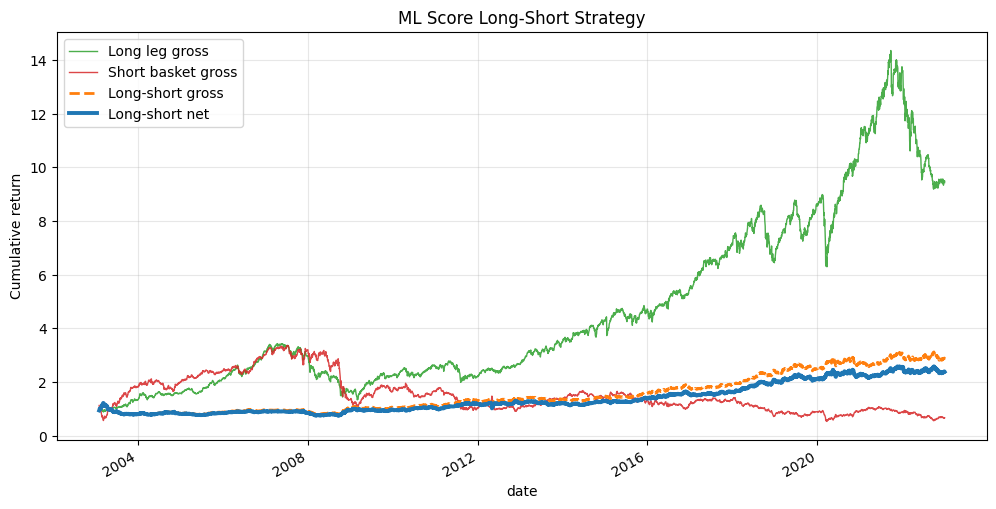

In [19]:
ls_cumulative = (1 + ls_returns).cumprod()

ax = ls_cumulative["Long Leg Gross"].plot(
    figsize=(12, 6),
    color="C2",
    linewidth=1.0,
    alpha=0.85,
    label="Long leg gross",
)
ls_cumulative["Short Basket Gross"].plot(
    ax=ax,
    color="C3",
    linewidth=1.0,
    alpha=0.85,
    label="Short basket gross",
)
ls_cumulative["Long-Short Gross"].plot(
    ax=ax,
    color="C1",
    linewidth=2.0,
    linestyle="--",
    label="Long-short gross",
)
ls_cumulative["Long-Short Net"].plot(
    ax=ax,
    color="C0",
    linewidth=2.8,
    label="Long-short net",
)

ax.set_title("ML Score Long-Short Strategy")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## Long and Short Basket Net Performance

The next two plots isolate the two baskets. The short basket is still shown before applying the short sign, so it represents the standalone performance of the low-score stocks.


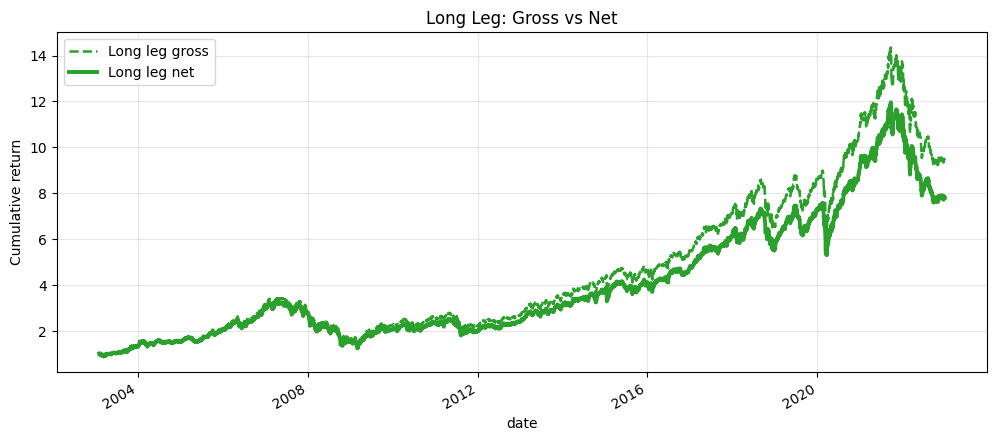

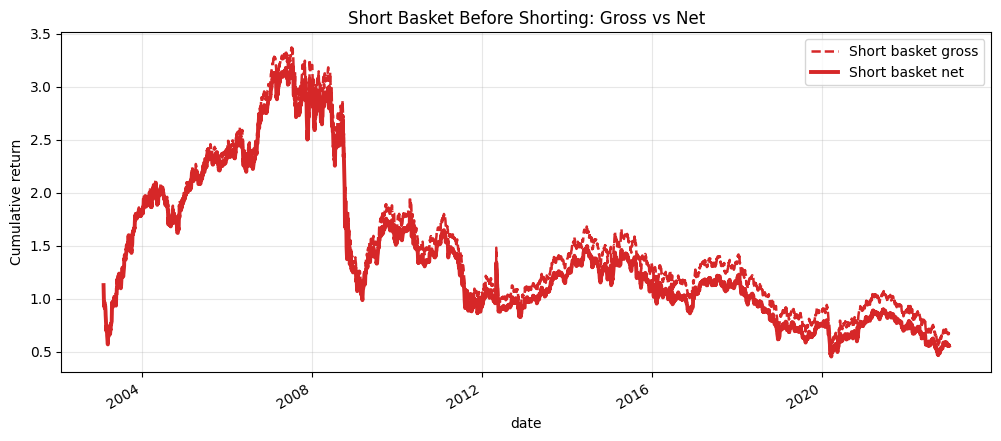

In [20]:
long_leg_plot = pd.concat(
    {
        "Long Leg Gross": long_leg_returns,
        "Long Leg Net": long_leg_returns_net,
    },
    axis=1,
).dropna()

ax = (1 + long_leg_plot).cumprod()["Long Leg Gross"].plot(
    figsize=(12, 5),
    color="C2",
    linewidth=1.8,
    linestyle="--",
    label="Long leg gross",
)
(1 + long_leg_plot).cumprod()["Long Leg Net"].plot(
    ax=ax,
    color="C2",
    linewidth=2.8,
    label="Long leg net",
)
ax.set_title("Long Leg: Gross vs Net")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

short_basket_plot = pd.concat(
    {
        "Short Basket Gross": short_basket_returns,
        "Short Basket Net": short_basket_returns_net,
    },
    axis=1,
).dropna()

ax = (1 + short_basket_plot).cumprod()["Short Basket Gross"].plot(
    figsize=(12, 5),
    color="C3",
    linewidth=1.8,
    linestyle="--",
    label="Short basket gross",
)
(1 + short_basket_plot).cumprod()["Short Basket Net"].plot(
    ax=ax,
    color="C3",
    linewidth=2.8,
    label="Short basket net",
)
ax.set_title("Short Basket Before Shorting: Gross vs Net")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


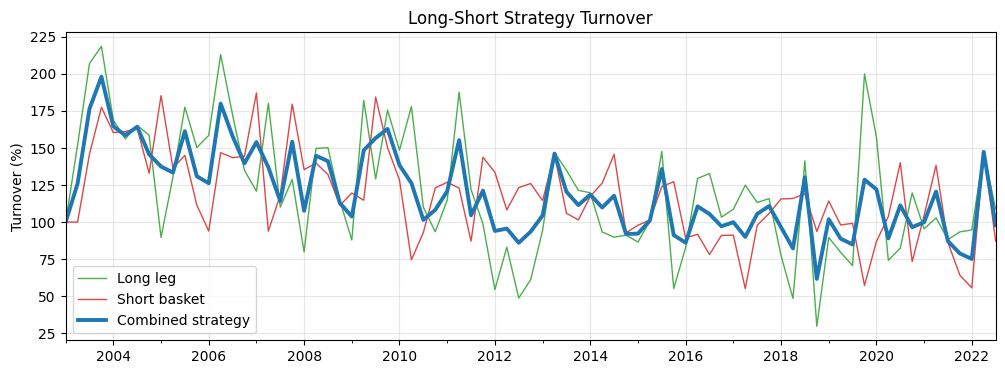

In [21]:
ls_turnover_summary = pd.concat(
    {
        "Long leg": long_turnover,
        "Short basket": short_turnover,
        "Combined strategy": ls_combined_turnover,
    },
    axis=1,
).dropna()

ax = (100 * ls_turnover_summary["Long leg"]).plot(
    figsize=(12, 4),
    color="C2",
    linewidth=1.0,
    alpha=0.85,
    label="Long leg",
)
(100 * ls_turnover_summary["Short basket"]).plot(
    ax=ax,
    color="C3",
    linewidth=1.0,
    alpha=0.85,
    label="Short basket",
)
(100 * ls_turnover_summary["Combined strategy"]).plot(
    ax=ax,
    color="C0",
    linewidth=2.8,
    label="Combined strategy",
)

ax.set_title("Long-Short Strategy Turnover")
ax.set_ylabel("Turnover (%)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## Long-Short Factor Analysis

The tables below show whether the long leg, short basket, and final long-short strategy are explained by the benchmark factors. A positive and significant alpha means that the return is not fully captured by the factor exposures in the regression.


In [22]:
ls_factor_inputs = {
    "Long Leg Net": long_leg_returns_net,
    "Short Basket Net": short_basket_returns_net,
    "Long-Short Net": ls_net_returns,
}

ls_factor_results = {
    name: factor_regression(
        strategy_returns=returns.rename(name),
        factor_returns=factor_returns,
        factor_columns=factor_columns,
    )
    for name, returns in ls_factor_inputs.items()
}

ls_factor_summary = pd.DataFrame(
    {name: result["summary"] for name, result in ls_factor_results.items()}
).T

ls_factor_betas = pd.DataFrame(
    {name: result["betas"] for name, result in ls_factor_results.items()}
).T

ls_factor_summary.round(4)


C:\Users\axeli\AppData\Local\Temp\ipykernel_7144\3290991403.py:42: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(
C:\Users\axeli\AppData\Local\Temp\ipykernel_7144\3290991403.py:42: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(
C:\Users\axeli\AppData\Local\Temp\ipykernel_7144\3290991403.py:42: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=F

,Alpha Daily,Annualized Alpha,Alpha t-stat,Residual Volatility,Information Ratio,R-squared,Observations
Long Leg Net,0.0001,0.0363,1.5328,0.1043,0.3480,0.6842,"4,997.0000"
Short Basket Net,0.0000,0.0021,0.0569,0.1659,0.0129,0.5815,"4,997.0000"
Long-Short Net,0.0000,0.0078,0.3599,0.0957,0.0817,0.1834,"4,997.0000"


In [23]:
ls_factor_betas.round(4)


,SPI,value,momentum,quality,investment,low_risk,size,short_term_reversal
Long Leg Net,0.5559,-0.3443,0.2447,0.5963,-0.0120,-0.7173,0.0257,0.1114
Short Basket Net,0.4283,0.0963,-0.3133,-0.0004,-0.3472,-1.5767,0.1475,0.2071
Long-Short Net,0.0624,-0.2174,0.2793,0.2974,0.1682,0.4299,-0.0646,-0.0500


## Implementation 2: Black-Litterman Long-Only Strategy

The second implementation converts the same ML score into Black-Litterman views. The optimizer controls risk, concentration, size limits, and turnover.


In [24]:
bl_optimization_builders = {
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    "cap_weights": OptimizationItemBuilder(bibfn=bibfn_cap_weights),
    "scores": OptimizationItemBuilder(bibfn=bibfn_scores, fields=["ml_signal"]),
    "budget_constraint": OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1,
    ),
    "box_constraints": OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        lower=0,
        upper=CONFIG.stock_upper_bound,
    ),
    "size_dependent_upper_bounds": OptimizationItemBuilder(
        bibfn=bibfn_size_dependent_upper_bounds,
        small_cap={"threshold": 300_000_000, "upper": 0.02},
        mid_cap={"threshold": 1_000_000_000, "upper": 0.05},
        large_cap={"threshold": 10_000_000_000, "upper": CONFIG.stock_upper_bound},
    ),
    "turnover_constraint": OptimizationItemBuilder(
        bibfn=bibfn_turnover_constraint,
        turnover_limit=CONFIG.turnover_limit,
    ),
}

tau_default = 1 / CONFIG.lookback_days
bl_optimizer = BlackLitterman(
    covariance=Covariance(method="pearson", check_positive_definite=True),
    tau_psi=CONFIG.tau_psi or tau_default,
    tau_omega=CONFIG.tau_omega or tau_default,
    view_gen_algo=CONFIG.view_gen_algo,
    use_unconditional_cov=True,
    signal_names=["ml_signal"],
    solver_name=CONFIG.solver_name,
)

bs_bl = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=bl_optimization_builders,
    optimization=bl_optimizer,
    rebdates=rebalance_dates,
    quiet=False,
)


In [25]:
# Run this cell when ready.
bt_bl = Backtest()
bt_bl.run(bs=bs_bl)


Running backtest: 100%|##########| 79/79 [05:50<00:00,  4.44s/it, 2022-07-31]


## Black-Litterman Returns and Costs

The Black-Litterman strategy is simulated gross first. Transaction costs and fixed costs are then applied manually.


In [26]:
bl_gross_returns = bt_bl.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("BL Gross")

bl_turnover = bt_bl.strategy.turnover(return_series=return_series, rescale=False)
bl_turnover.index = pd.to_datetime(bl_turnover.index)

bl_net_returns = subtract_rebalance_costs(
    gross_returns=bl_gross_returns,
    turnover=bl_turnover,
    transaction_cost=CONFIG.transaction_costs_per_rebalancing,
)
bl_net_returns = apply_fixed_cost_drag(
    returns=bl_net_returns,
    fixed_costs_annual=CONFIG.fixed_costs_annual,
).rename("BL Net")

bl_returns = pd.concat(
    {
        "SPI": data.bm_series,
        "BL Gross": bl_gross_returns,
        "BL Net": bl_net_returns,
    },
    axis=1,
).dropna()

if CONFIG.end_date is not None:
    bl_returns = bl_returns[bl_returns.index <= CONFIG.end_date]

bl_returns.head()


,SPI,BL Gross,BL Net
2003-02-03,0.0110,0.0084,0.0064
2003-02-04,-0.0240,-0.0127,-0.0127
2003-02-05,0.0057,-0.0034,-0.0035
2003-02-06,-0.0267,-0.0146,-0.0146
2003-02-07,-0.0079,-0.0139,-0.0139


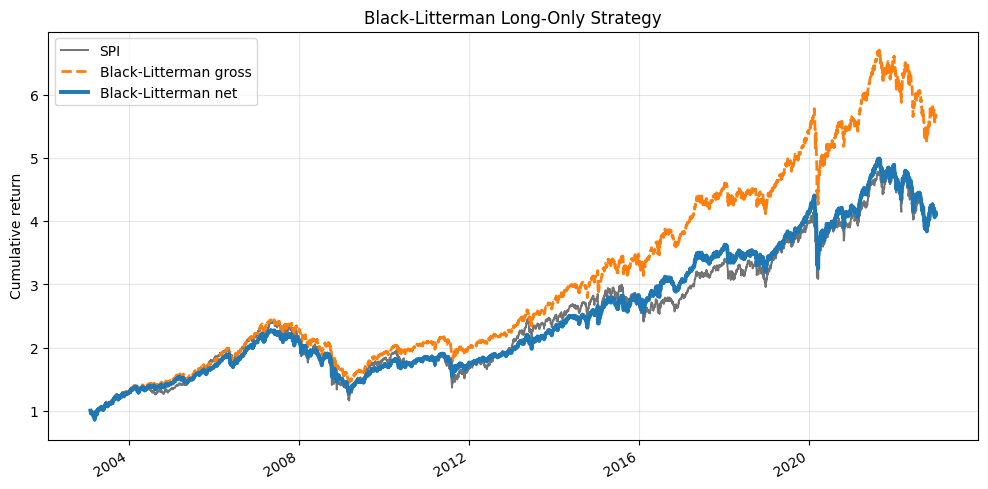

In [27]:
bl_cumulative = (1 + bl_returns).cumprod()

ax = bl_cumulative["SPI"].plot(
    figsize=(12, 6),
    color="0.45",
    linewidth=1.4,
    label="SPI",
)
bl_cumulative["BL Gross"].plot(
    ax=ax,
    color="C1",
    linewidth=2.0,
    linestyle="--",
    label="Black-Litterman gross",
)
bl_cumulative["BL Net"].plot(
    ax=ax,
    color="C0",
    linewidth=2.8,
    label="Black-Litterman net",
)

ax.set_title("Black-Litterman Long-Only Strategy")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


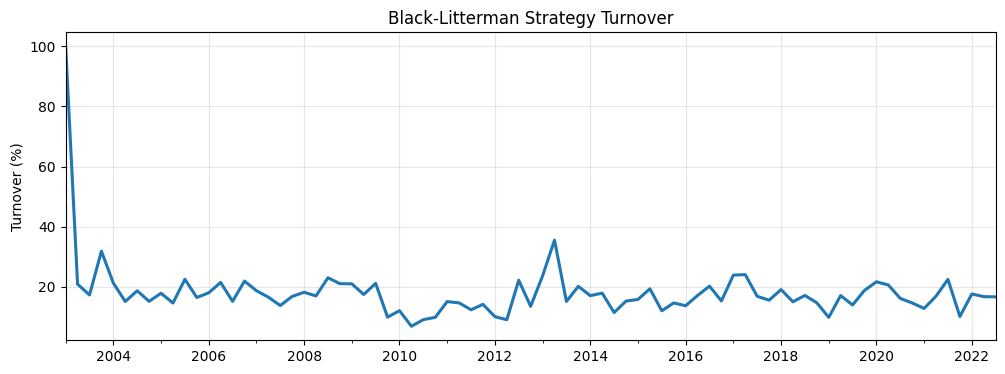

In [28]:
ax = (100 * bl_turnover).plot(
    figsize=(12, 4),
    color="C0",
    linewidth=2.2,
)
ax.set_title("Black-Litterman Strategy Turnover")
ax.set_ylabel("Turnover (%)")
ax.grid(True, alpha=0.3)
plt.show()


## Black-Litterman Factor Analysis

The Black-Litterman strategy uses the same ML score, but the optimizer imposes long-only, risk, concentration, and turnover constraints. The factor regression checks whether the resulting net return still has alpha after those constraints.


In [29]:
bl_factor_results = {
    "Black-Litterman Net": factor_regression(
        strategy_returns=bl_net_returns.rename("Black-Litterman Net"),
        factor_returns=factor_returns,
        factor_columns=factor_columns,
    )
}

bl_factor_summary = pd.DataFrame(
    {name: result["summary"] for name, result in bl_factor_results.items()}
).T

bl_factor_betas = pd.DataFrame(
    {name: result["betas"] for name, result in bl_factor_results.items()}
).T

bl_factor_summary.round(4)


C:\Users\axeli\AppData\Local\Temp\ipykernel_7144\3290991403.py:42: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(


,Alpha Daily,Annualized Alpha,Alpha t-stat,Residual Volatility,Information Ratio,R-squared,Observations
Black-Litterman Net,0.0001,0.0152,1.4295,0.0469,0.3246,0.8488,"4,997.0000"


In [30]:
bl_factor_betas.round(4)


,SPI,value,momentum,quality,investment,low_risk,size,short_term_reversal
Black-Litterman Net,0.6594,-0.1355,0.0117,0.2032,0.0008,-0.0319,0.0567,-0.0012


## Final Comparison

The final comparison includes the SPI benchmark, the standalone net long leg, the standalone net short basket before shorting, the final long-short net strategy, and the Black-Litterman net strategy.

This helps answer four separate questions:

- does the ML signal identify good stocks in the long leg?
- does it identify weak stocks in the low-score basket?
- does the top-minus-bottom spread survive transaction costs?
- does the same signal still work after Black-Litterman long-only constraints?


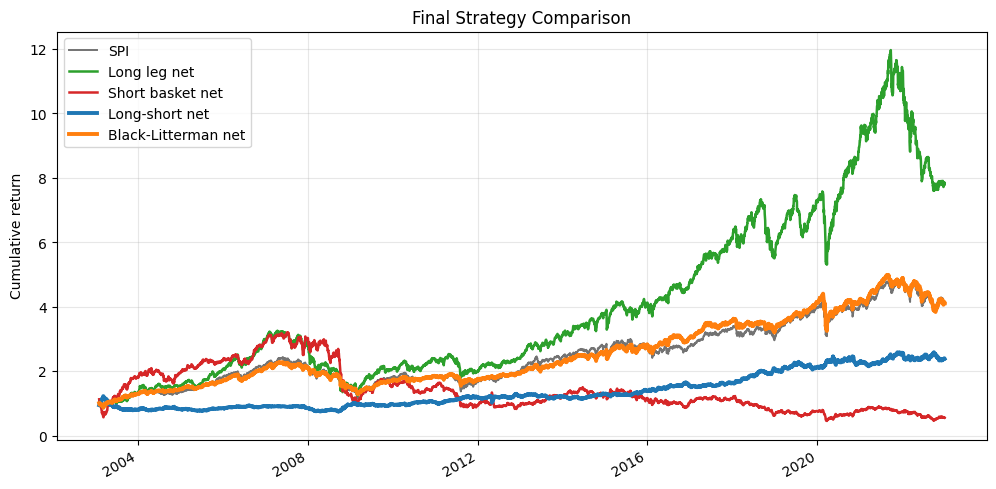

In [31]:
final_returns = pd.concat(
    {
        "SPI": data.bm_series,
        "Long Leg Net": long_leg_returns_net,
        "Short Basket Net": short_basket_returns_net,
        "Long-Short Net": ls_net_returns,
        "Black-Litterman Net": bl_net_returns,
    },
    axis=1,
).dropna()

if CONFIG.end_date is not None:
    final_returns = final_returns[final_returns.index <= CONFIG.end_date]

turnover_map = {
    "Long Leg Net": long_turnover,
    "Short Basket Net": short_turnover,
    "Long-Short Net": ls_combined_turnover,
    "Black-Litterman Net": bl_turnover,
}

final_cumulative = (1 + final_returns).cumprod()

ax = final_cumulative["SPI"].plot(
    figsize=(12, 6),
    color="0.45",
    linewidth=1.4,
    label="SPI",
)
final_cumulative["Long Leg Net"].plot(
    ax=ax,
    color="C2",
    linewidth=1.8,
    label="Long leg net",
)
final_cumulative["Short Basket Net"].plot(
    ax=ax,
    color="C3",
    linewidth=1.8,
    label="Short basket net",
)
final_cumulative["Long-Short Net"].plot(
    ax=ax,
    color="C0",
    linewidth=2.8,
    label="Long-short net",
)
final_cumulative["Black-Litterman Net"].plot(
    ax=ax,
    color="C1",
    linewidth=2.8,
    label="Black-Litterman net",
)

ax.set_title("Final Strategy Comparison")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## Performance Metrics

The table reports return, risk, drawdown, final cumulative return, and average turnover for each implementation.


In [32]:
final_performance = performance_table(
    returns=final_returns,
    turnover_map=turnover_map,
)

final_factor_inputs = {
    "Long Leg Net": long_leg_returns_net,
    "Short Basket Net": short_basket_returns_net,
    "Long-Short Net": ls_net_returns,
    "Black-Litterman Net": bl_net_returns,
}

final_factor_results = {
    name: factor_regression(
        strategy_returns=returns.rename(name),
        factor_returns=factor_returns,
        factor_columns=factor_columns,
    )
    for name, returns in final_factor_inputs.items()
}

final_factor_summary = pd.DataFrame(
    {name: result["summary"] for name, result in final_factor_results.items()}
).T

final_factor_betas = pd.DataFrame(
    {name: result["betas"] for name, result in final_factor_results.items()}
).T

final_performance.round(4)


C:\Users\axeli\AppData\Local\Temp\ipykernel_7144\3290991403.py:42: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(
C:\Users\axeli\AppData\Local\Temp\ipykernel_7144\3290991403.py:42: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(
C:\Users\axeli\AppData\Local\Temp\ipykernel_7144\3290991403.py:42: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=F

,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Final Cumulative Return,Average Turnover
SPI,0.0714,0.1618,0.4409,-0.5216,3.1069,NaN
Long Leg Net,0.1054,0.1826,0.5772,-0.6176,6.7950,1.2093
Short Basket Net,-0.0282,0.2522,-0.1118,-0.8585,-0.4436,1.1777
Long-Short Net,0.0433,0.1042,0.4158,-0.3933,1.3855,1.1935
Black-Litterman Net,0.0713,0.1187,0.6008,-0.4365,3.1035,0.1807


In [33]:
final_factor_summary.round(4)


,Alpha Daily,Annualized Alpha,Alpha t-stat,Residual Volatility,Information Ratio,R-squared,Observations
Long Leg Net,0.0001,0.0363,1.5328,0.1043,0.3480,0.6842,"4,997.0000"
Short Basket Net,0.0000,0.0021,0.0569,0.1659,0.0129,0.5815,"4,997.0000"
Long-Short Net,0.0000,0.0078,0.3599,0.0957,0.0817,0.1834,"4,997.0000"
Black-Litterman Net,0.0001,0.0152,1.4295,0.0469,0.3246,0.8488,"4,997.0000"


In [34]:
final_factor_betas.round(4)


,SPI,value,momentum,quality,investment,low_risk,size,short_term_reversal
Long Leg Net,0.5559,-0.3443,0.2447,0.5963,-0.0120,-0.7173,0.0257,0.1114
Short Basket Net,0.4283,0.0963,-0.3133,-0.0004,-0.3472,-1.5767,0.1475,0.2071
Long-Short Net,0.0624,-0.2174,0.2793,0.2974,0.1682,0.4299,-0.0646,-0.0500
Black-Litterman Net,0.6594,-0.1355,0.0117,0.2032,0.0008,-0.0319,0.0567,-0.0012


## Accessing Weights and Scores

The saved score panel and weight matrices make later diagnostics faster. They avoid retraining the ML model or rerunning the full backtests when we only need scores or portfolio weights.


In [35]:
def strategy_weights(strategy) -> pd.DataFrame:
    """Convert stored portfolios into a rebalance-date by stock-id weight matrix."""
    weights = pd.DataFrame(
        {
            portfolio.rebalancing_date: pd.Series(portfolio.weights, dtype=float)
            for portfolio in strategy.portfolios
        }
    ).T.fillna(0)
    weights.index = pd.to_datetime(weights.index)
    return weights.sort_index()


long_weights = strategy_weights(bt_long.strategy)
short_basket_weights = strategy_weights(bt_short.strategy)
bl_weights = strategy_weights(bt_bl.strategy)

all_ids = long_weights.columns.union(short_basket_weights.columns)
long_weights = long_weights.reindex(columns=all_ids, fill_value=0)
short_basket_weights = short_basket_weights.reindex(columns=all_ids, fill_value=0)

long_short_signed_weights = (
    CONFIG.long_weight * long_weights
    + CONFIG.short_weight * short_basket_weights
).fillna(0)

ml_signal.to_frame().to_parquet(CONFIG.signal_path)
long_weights.to_parquet(CONFIG.results_dir / "matilde_long_weights.parquet")
short_basket_weights.to_parquet(CONFIG.results_dir / "matilde_short_weights.parquet")
long_short_signed_weights.to_parquet(CONFIG.results_dir / "matilde_long_short_signed_weights.parquet")
bl_weights.to_parquet(CONFIG.results_dir / "matilde_bl_weights.parquet")

pd.DataFrame(
    {
        "rows": [
            len(ml_signal),
            len(long_weights),
            len(short_basket_weights),
            len(long_short_signed_weights),
            len(bl_weights),
        ],
        "columns": [
            1,
            long_weights.shape[1],
            short_basket_weights.shape[1],
            long_short_signed_weights.shape[1],
            bl_weights.shape[1],
        ],
    },
    index=[
        "ml_signal",
        "long_weights",
        "short_basket_weights",
        "long_short_signed_weights",
        "bl_weights",
    ],
)


,rows,columns
ml_signal,32806,1
long_weights,79,130
short_basket_weights,79,130
long_short_signed_weights,79,130
bl_weights,79,150


## Final Interpretation

This notebook now has one shared ML signal and two portfolio implementations. The long-short strategy tests whether the score works as a direct top-minus-bottom spread. The Black-Litterman strategy tests whether the same score improves a constrained long-only portfolio after risk, concentration, and turnover controls.

The next checks are signal stability, turnover, transaction-cost sensitivity, subperiod performance, constraint tuning, and robustness of the volatility-scaled mean-reversion feature.
